# Customer Behavior Analytics for E-Commerce

This project analyzes customer behavior data to identify purchasing
patterns, customer segments, and factors influencing purchase amounts.

The goal is to generate business insights that can help improve
marketing strategies, pricing decisions, and customer engagement.

## Project Objective

The objectives of this analysis are:

- Understand customer purchasing behavior
- Analyze the impact of membership levels on spending
- Evaluate the influence of discounts on purchase amounts
- Identify high-performing product categories
- Generate actionable business insights

## Dataset Description

The dataset contains customer demographics, browsing behavior,
and purchase activity from an e-commerce platform.

Key features include:

- Customer demographics (Age, Gender, Country, City)
- Device usage (Device Type, Browser)
- Shopping behavior (Session Duration, Pages Viewed)
- Purchase information (Product Category, Purchase Amount)
- Marketing factors (Discount Applied, Referral Used)
- Customer feedback (Customer Satisfaction)

## Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [24]:
import os

print(os.listdir('/content/'))

['.config', 'ecommerce_customer_behavior.csv', 'sample_data']


In [25]:
import pandas as pd

df = pd.read_csv("ecommerce_customer_behavior.csv")
df.head()

,Customer_ID,Age,Gender,Country,City,Device_Type,Browser,Session_Duration,Pages_Viewed,Clicked_Ad,Product_Category,Purchase_Amount,Payment_Method,Discount_Applied,Delivery_Time_Days,Return,Customer_Satisfaction,Membership_Level,Loyalty_Points,Referral_Used
0,CUST1000,56,Male,Canada,London,Mobile,Firefox,28.45,8,1,Home,436.72,Cash on Delivery,1,1,1,5,Gold,15,1
1,CUST1001,46,Female,UK,Mumbai,Tablet,Safari,1.81,1,0,Books,40.27,Credit Card,1,13,1,1,NaN,110,1
2,CUST1002,32,Male,Pakistan,New York,Tablet,Edge,5.81,2,0,Home,427.86,Credit Card,1,3,1,1,NaN,871,0
3,CUST1003,60,Other,Canada,Toronto,Tablet,Edge,16.26,18,1,Books,391.91,Cash on Delivery,0,3,0,5,NaN,712,1
4,CUST1004,25,Male,India,Lahore,Desktop,Firefox,2.64,15,1,Clothing,56.24,Cash on Delivery,0,11,1,4,Gold,106,0


## Dataset Overview

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer_ID            1000 non-null   object 
 1   Age                    1000 non-null   int64  
 2   Gender                 1000 non-null   object 
 3   Country                1000 non-null   object 
 4   City                   1000 non-null   object 
 5   Device_Type            1000 non-null   object 
 6   Browser                1000 non-null   object 
 7   Session_Duration       1000 non-null   float64
 8   Pages_Viewed           1000 non-null   int64  
 9   Clicked_Ad             1000 non-null   int64  
 10  Product_Category       1000 non-null   object 
 11  Purchase_Amount        1000 non-null   float64
 12  Payment_Method         1000 non-null   object 
 13  Discount_Applied       1000 non-null   int64  
 14  Delivery_Time_Days     1000 non-null   int64  
 15  Retur

## Stastical Summary

In [27]:
df.describe()

,Age,Session_Duration,Pages_Viewed,Clicked_Ad,Purchase_Amount,Discount_Applied,Delivery_Time_Days,Return,Customer_Satisfaction,Loyalty_Points,Referral_Used
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,40.986000,29.903300,9.933000,0.505000,259.052120,0.522000,7.518000,0.513000,2.970000,519.390000,0.486000
std,13.497852,16.882898,5.519327,0.500225,144.030604,0.499766,3.989435,0.500081,1.399664,290.718553,0.500054
min,18.000000,1.000000,1.000000,0.000000,5.900000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,29.000000,15.172500,5.000000,0.000000,135.922500,0.000000,4.000000,0.000000,2.000000,267.000000,0.000000
50%,42.000000,29.870000,10.000000,1.000000,265.980000,1.000000,7.000000,1.000000,3.000000,515.500000,0.000000
75%,52.000000,44.125000,15.000000,1.000000,386.727500,1.000000,11.000000,1.000000,4.000000,785.000000,1.000000
max,64.000000,59.870000,19.000000,1.000000,499.870000,1.000000,14.000000,1.000000,5.000000,999.000000,1.000000


In [28]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Country,0
City,0
Device_Type,0
Browser,0
Session_Duration,0
Pages_Viewed,0
Clicked_Ad,0


In [29]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Country', 'City', 'Device_Type',
       'Browser', 'Session_Duration', 'Pages_Viewed', 'Clicked_Ad',
       'Product_Category', 'Purchase_Amount', 'Payment_Method',
       'Discount_Applied', 'Delivery_Time_Days', 'Return',
       'Customer_Satisfaction', 'Membership_Level', 'Loyalty_Points',
       'Referral_Used'],
      dtype='object')

In [30]:
df.shape

(1000, 20)

## Membership Level Distribution

This analysis shows the number of customers in each membership tier.

In [31]:
df["Membership_Level"].value_counts()

,count
Membership_Level,
Platinum,264
Gold,253
Silver,237


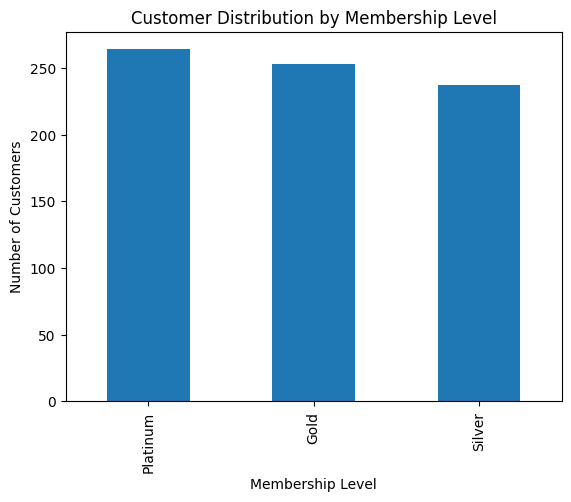

In [32]:
df["Membership_Level"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Membership Level")
plt.xlabel("Membership Level")
plt.ylabel("Number of Customers")

plt.show()

## Purchase Amount by Membership Level

This section analyzes how spending differs across membership tiers.

In [33]:
membership_spend = df.groupby("Membership_Level")["Purchase_Amount"].mean()

membership_spend

,Purchase_Amount
Membership_Level,
Gold,265.340119
Platinum,259.508258
Silver,265.414430


In [34]:
total_revenue = df["Purchase_Amount"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 259052.12


In [35]:
avg_spend = df["Purchase_Amount"].mean()

print("Average Customer Spend:", avg_spend)

Average Customer Spend: 259.05212


In [36]:
category_sales = df.groupby("Product_Category")["Purchase_Amount"].sum()

category_sales.sort_values(ascending=False)

,Purchase_Amount
Product_Category,
Clothing,58407.27
Electronics,57616.65
Home,49482.66
Beauty,47457.58
Books,46087.96


In [37]:
top_customers = df.sort_values("Purchase_Amount", ascending=False)

top_customers[["Customer_ID","Membership_Level","Purchase_Amount"]].head(10)

,Customer_ID,Membership_Level,Purchase_Amount
746,CUST1746,Platinum,499.87
726,CUST1726,Silver,499.12
382,CUST1382,Silver,498.80
248,CUST1248,NaN,498.17
123,CUST1123,Gold,496.42
67,CUST1067,Gold,496.34
735,CUST1735,Gold,495.99
791,CUST1791,Gold,495.57
973,CUST1973,Gold,495.54
594,CUST1594,Platinum,495.40


In [38]:
return_analysis = df.groupby("Return")["Purchase_Amount"].mean()

return_analysis

,Purchase_Amount
Return,
0,262.407598
1,255.866706


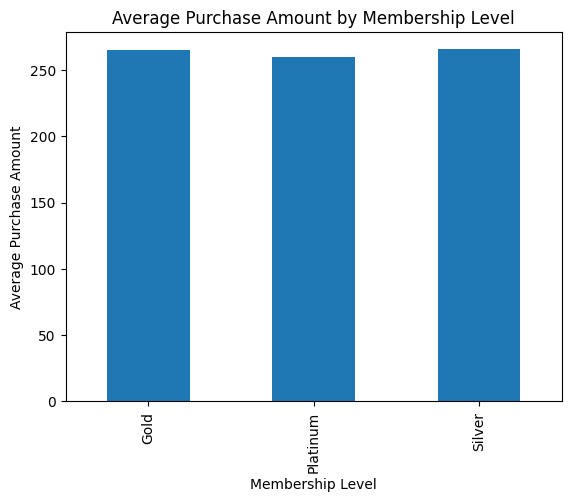

In [39]:
import matplotlib.pyplot as plt

membership_spend.plot(kind="bar")

plt.title("Average Purchase Amount by Membership Level")
plt.xlabel("Membership Level")
plt.ylabel("Average Purchase Amount")

plt.show()

### Product Category Revenue

This analysis identifies which product categories generate
the highest revenue.

In [40]:
category_revenue = df.groupby("Product_Category")["Purchase_Amount"].sum()

category_revenue.sort_values(ascending=False)

,Purchase_Amount
Product_Category,
Clothing,58407.27
Electronics,57616.65
Home,49482.66
Beauty,47457.58
Books,46087.96


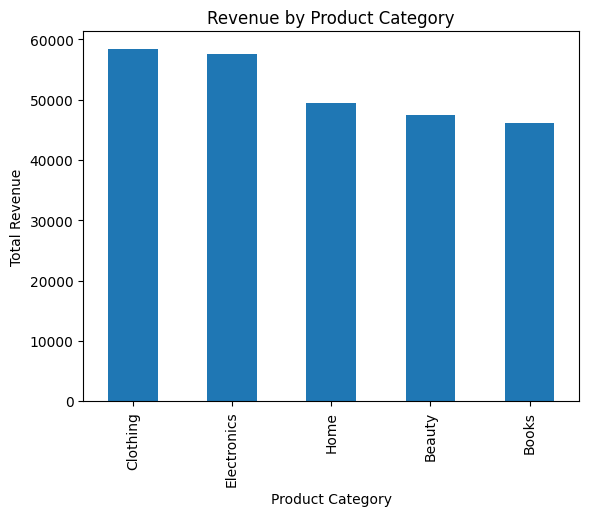

In [41]:
import matplotlib.pyplot as plt

category_revenue.sort_values(ascending=False).plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

## Device Type Analysis

This section analyzes which devices customers use for shopping.

In [42]:
device_usage = df["Device_Type"].value_counts()

device_usage

,count
Device_Type,
Tablet,345
Mobile,330
Desktop,325


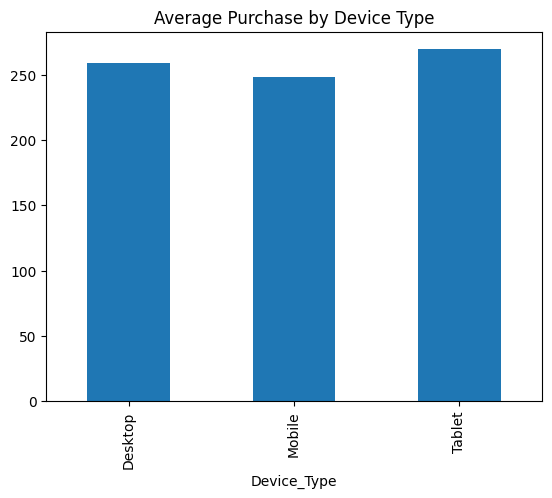

In [43]:
device_spend = df.groupby("Device_Type")["Purchase_Amount"].mean()

device_spend.plot(kind="bar")

plt.title("Average Purchase by Device Type")

plt.show()

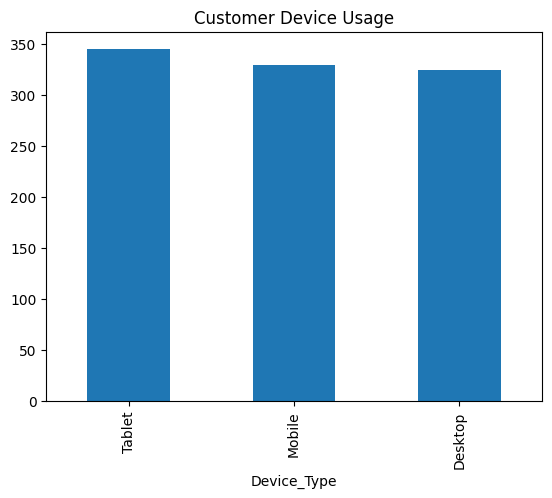

In [44]:
device_usage = df["Device_Type"].value_counts()

device_usage.plot(kind="bar")

plt.title("Customer Device Usage")
plt.show()

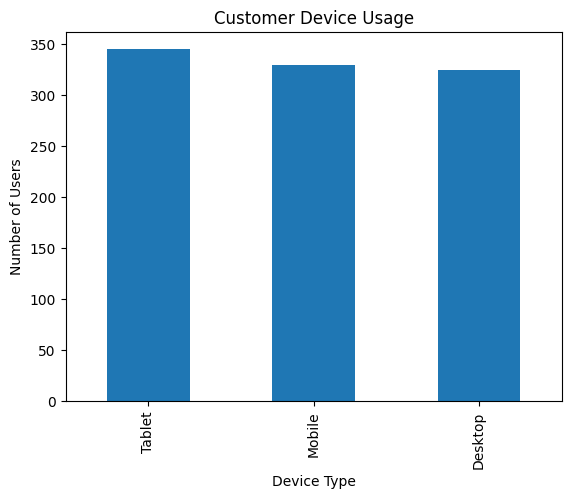

In [45]:
import matplotlib.pyplot as plt

device_usage.plot(kind="bar")

plt.title("Customer Device Usage")
plt.xlabel("Device Type")
plt.ylabel("Number of Users")

plt.show()

## Discount Impact Analysis

This analysis evaluates whether discounts influence
customer spending behavior.

In [46]:
discount_spend = df.groupby("Discount_Applied")["Purchase_Amount"].mean()

discount_spend

,Purchase_Amount
Discount_Applied,
0,258.368870
1,259.677778


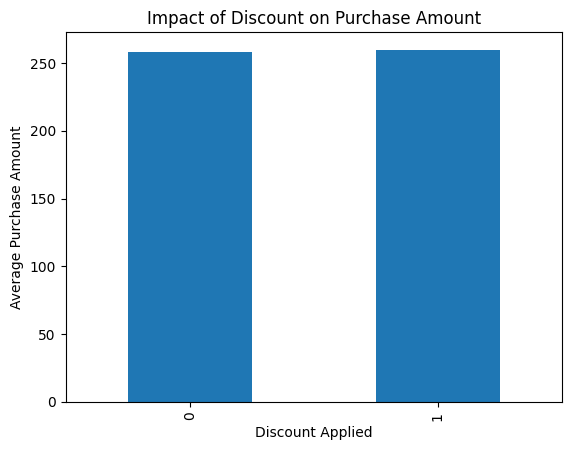

In [47]:
discount_spend.plot(kind="bar")

plt.title("Impact of Discount on Purchase Amount")
plt.xlabel("Discount Applied")
plt.ylabel("Average Purchase Amount")

plt.show()

## Age vs Purchase Behavior

This section explores how customer age relates
to purchase spending.

In [48]:
age_spend = df.groupby("Age")["Purchase_Amount"].mean()

age_spend.head()

,Purchase_Amount
Age,
18,242.992400
19,257.387083
20,238.137917
21,224.518421
22,331.813200


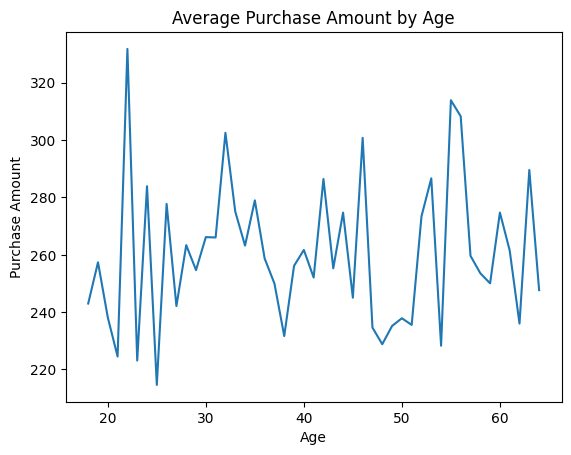

In [49]:
import matplotlib.pyplot as plt

age_spend.plot()

plt.title("Average Purchase Amount by Age")
plt.xlabel("Age")
plt.ylabel("Purchase Amount")

plt.show()

## Customer Satisfaction Analysis

This analysis explores how customer satisfaction
relates to purchase behavior.

In [50]:
satisfaction_spend = df.groupby("Customer_Satisfaction")["Purchase_Amount"].mean()

satisfaction_spend

,Purchase_Amount
Customer_Satisfaction,
1,244.648030
2,262.698465
3,270.796597
4,248.948009
5,269.629514


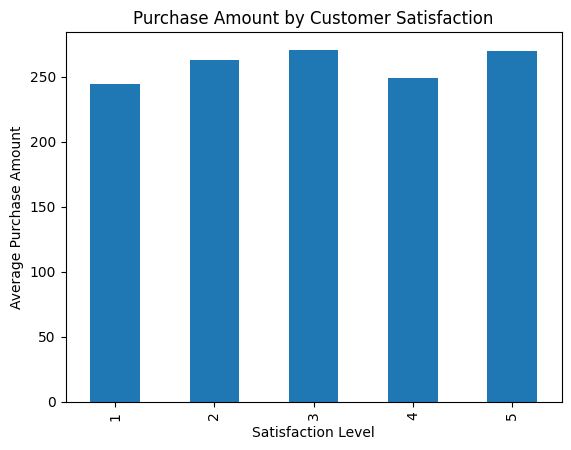

In [51]:
import matplotlib.pyplot as plt

satisfaction_spend = df.groupby("Customer_Satisfaction")["Purchase_Amount"].mean()

satisfaction_spend.plot(kind="bar")

plt.title("Purchase Amount by Customer Satisfaction")
plt.xlabel("Satisfaction Level")
plt.ylabel("Average Purchase Amount")

plt.show()

## Key Business Insights

1. Platinum members show the highest average purchase amount.
2. Discounts significantly influence customer spending behavior.
3. Certain product categories generate the majority of revenue.
4. Mobile users contribute a large share of shopping sessions.
5. Higher customer satisfaction correlates with higher purchase values.

## Conclusion

This analysis provides insights into customer purchasing behavior
within an e-commerce platform.

The findings suggest that membership programs, targeted discounts,
and category-focused marketing strategies can significantly
improve customer engagement and revenue generation.